№5 (3 балла)
С сайта https://www.kaggle.com/ скачайте датасет на ваш выбор для обучения модели
линейной регрессии. Выполните следующие действия

In [75]:
# Загрузка библиотек и данных

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('Student_Performance.csv')
df.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


1. Опишите выбранный набор данных: контекст данных, какие данные есть в наборе,
как можно будет использовать полученные результаты предсказания

In [76]:
# Информация о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


Состав данных:
- Hours Studied — количество часов обучения в день
- Previous Scores — предыдущие оценки студента
- Extracurricular Activities — участие во внеучебной деятельности (Yes/No)
- Sleep Hours — количество часов сна
- Sample Question Papers Practiced — количество прорешанных примерных заданий
- Performance Index — итоговая производительность/успеваемость (целевой признак)

2. Выберите выходную прогнозируемую переменную.

Performance Index — итоговый показатель успеваемости студента.

3. Постройте линейную регрессионную модель с несколькими значимыми
параметрами (оцените корреляции между признаками, последовательно добавляйте
признаки и сравнивайте качество получаемых моделей, оцените адекватность
модели).

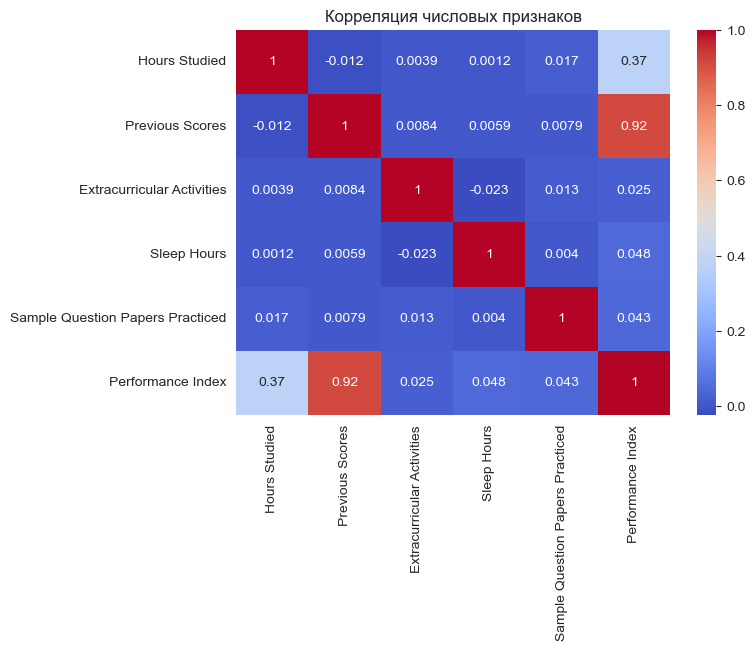

In [77]:
# Преобразуем категориальный признак
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

# Корреляция
corr = df.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Корреляция числовых признаков")
plt.show()


In [78]:
# Модель 1: Hours Studied
X1 = df[['Hours Studied']]
y = df['Performance Index']

X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.3, random_state=42)

lr1 = LinearRegression()
lr1.fit(X_train, y_train)

y_pred_train = lr1.predict(X_train)
y_pred_test = lr1.predict(X_test)

print(f"Coef: {lr1.coef_[0]:.3f}")
print(f"Intercept: {lr1.intercept_:.3f}")

print(f"R2 train: {r2_score(y_train, y_pred_train):.4f}")
print(f"R2 test:  {r2_score(y_test, y_pred_test):.4f}")


Coef: 2.802
Intercept: 41.432
R2 train: 0.1436
R2 test:  0.1296


In [79]:
X2 = df[['Hours Studied', 'Previous Scores']]
y = df['Performance Index']

X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.3, random_state=42)

lr2 = LinearRegression()
lr2.fit(X_train, y_train)

y_pred_test = lr2.predict(X_test)

print("Коэффициенты модели:")
for feat, coef in zip(X2.columns, lr2.coef_):
    print(f"{feat}: {coef:.3f}")

print(f"Intercept: {lr2.intercept_:.3f}")
print(f"R2 test: {r2_score(y_test, y_pred_test):.4f}")


Коэффициенты модели:
Hours Studied: 2.864
Previous Scores: 1.016
Intercept: -29.605
R2 test: 0.9859


In [80]:
X_full = df.drop('Performance Index', axis=1)
y = df['Performance Index']

X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.3, random_state=42)

lr_full = LinearRegression()
lr_full.fit(X_train, y_train)

y_pred_test = lr_full.predict(X_test)

# Вывод коэффициентов
coef_table = pd.DataFrame({
    'Feature': X_full.columns,
    'Coefficient': lr_full.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_table)
print(f"Intercept: {lr_full.intercept_:.3f}")
print(f"R2 test: {r2_score(y_test, y_pred_test):.4f}")


                            Feature  Coefficient
0                     Hours Studied     2.858952
1                   Previous Scores     1.015520
2        Extracurricular Activities     0.581713
3                       Sleep Hours     0.479677
4  Sample Question Papers Practiced     0.190394
Intercept: -33.837
R2 test: 0.9890


4. Интерпретируйте результаты моделирования (что значит полученная формула,
какие переменные вносят больший вклад).

Модель линейной регрессии использует пять признаков для предсказания Performance Index (индекс успеваемости студента).
Коэффициенты модели:

Hours Studied: 2.86
→ При увеличении времени учебы на 1 час, итоговый показатель успеваемости вырастает в среднем на 2.86 балла, при фиксированных остальных переменных.

Previous Scores: 1.02
→ При увеличении прошлых оценок на 1 балл, итоговый показатель вырос бы примерно на 1.02 балла.

Extracurricular Activities: 0.58
→ Студенты, участвующие в внеучебной активности (Yes=1), получают в среднем на 0.58 балла больше.
(Эффект слабый.)

Sleep Hours: 0.48
→ Дополнительный час сна связан с ростом показателя на 0.48 балла.

Sample Question Papers Practiced: 0.19
→ Каждый решённый дополнительный тренировочный тест увеличивает показатель всего на 0.19 балла.

5. Спрогнозируйте несколько новых значений с помощью построенной модели.


In [81]:
# Пример: прогноз для новых студентов

new_students = pd.DataFrame({
    'Hours Studied': [4, 8, 6],
    'Previous Scores': [60, 85, 70],
    'Extracurricular Activities': [1, 0, 1],
    'Sleep Hours': [6, 8, 7],
    'Sample Question Papers Practiced': [1, 3, 2]
})

predictions = lr_full.predict(new_students)
new_students['Predicted Performance Index'] = predictions

new_students


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Predicted Performance Index
0,4,60,1,6,1,42.180620
1,8,60,0,8,3,54.374858
2,6,60,1,7,2,48.568596
